In [1]:
import polars as pl
import numpy as np
import pandas as pd
from sklearn.linear_model import PoissonRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import skellam
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')


In [2]:
# Load and prepare data (memory-efficient approach)
print("Loading and preparing data...")
df = pl.read_parquet("../../data/processed/df_feat_final_result_optimized.parquet")
print(f"Original dataset size: {df.shape[0]:,} rows")

# Handle nulls (same as original baseline)
null_counts = df.null_count().to_dict(as_series=False)
cols_to_fill = [col for col in df.columns if (not col.startswith('weather_')) and (null_counts[col][0] > 0)]
df = df.with_columns([pl.col(col).fill_null(0) for col in cols_to_fill])
df = df.drop_nulls()

print(f"After cleaning: {df.shape[0]:,} rows")
print(f"Shape: {df.shape}")
print(f"Columns available: {len(df.columns)}")


Loading and preparing data...
Original dataset size: 25,613,290 rows
After cleaning: 25,561,948 rows
Shape: (25561948, 73)
Columns available: 73


In [3]:
# Analyze station distribution and select active stations
station_counts = df.group_by('station_id').agg(pl.count().alias('count')).sort('count', descending=True)
print(f"Total stations: {len(station_counts)}")
print(f"Station data distribution:")
print(station_counts.head(10))

# Filter for stations with sufficient data (at least 5000 samples for robust modeling)
min_samples = 5000
active_stations = station_counts.filter(pl.col('count') >= min_samples)
print(f"\nStations with >= {min_samples} samples: {len(active_stations)}")
print(f"Coverage: {active_stations['count'].sum() / df.shape[0] * 100:.1f}% of data")

# Get list of active station IDs
active_station_ids = active_stations['station_id'].to_list()
print(f"Active station IDs: {active_station_ids[:10]}...")  # Show first 10


Total stations: 398
Station data distribution:
shape: (10, 2)
┌────────────┬───────┐
│ station_id ┆ count │
│ ---        ┆ ---   │
│ i32        ┆ u32   │
╞════════════╪═══════╡
│ 252        ┆ 64226 │
│ 424        ┆ 64226 │
│ 190        ┆ 64226 │
│ 496        ┆ 64226 │
│ 20         ┆ 64226 │
│ 41         ┆ 64226 │
│ 371        ┆ 64226 │
│ 124        ┆ 64226 │
│ 337        ┆ 64226 │
│ 61         ┆ 64226 │
└────────────┴───────┘

Stations with >= 5000 samples: 398
Coverage: 100.0% of data
Active station IDs: [252, 424, 190, 496, 20, 41, 371, 124, 337, 61]...


In [4]:
# Define feature set (exclude station-specific features for per-station modeling)
feature_cols = [
    # Historical intensity (lagged features)
    'dep_last_DT', 'trip_dur_mean_last_DT',
    'dep_lag_1', 'dep_lag_2', 'dep_lag_3', 'dep_lag_4', 'dep_lag_5', 'dep_lag_6',
    'arr_last_DT', 'arr_lag_1', 'arr_lag_2', 'arr_lag_3', 'arr_lag_4', 'arr_lag_5', 'arr_lag_6',
    
    # Weather features
    'weather_temperature_2m', 'weather_relative_humidity_2m', 'weather_apparent_temperature',
    'weather_precipitation', 'weather_wind_speed_10m', 'weather_sunshine_duration', 'weather_is_day',
    
    # Temporal features (cyclical encoding)
    'sin_hour', 'cos_hour', 'sin_dow', 'cos_dow', 'sin_month', 'cos_month',
    
    # Calendar features
    'is_holiday_ar', 'is_weekend', 'payday_flag', 'vacation_season', 'peak_commute'
]

# Note: Exclude lat/lon since we're modeling per station
target_A = 'y_arrivals_next_DT'
target_D = 'y_departures_next_DT'

print(f"Features for per-station modeling: {len(feature_cols)}")
print("Features:", feature_cols[:10], "...")  # Show first 10


Features for per-station modeling: 33
Features: ['dep_last_DT', 'trip_dur_mean_last_DT', 'dep_lag_1', 'dep_lag_2', 'dep_lag_3', 'dep_lag_4', 'dep_lag_5', 'dep_lag_6', 'arr_last_DT', 'arr_lag_1'] ...


In [32]:
# Per-Station Probabilistic Baseline Function
def train_station_baseline(station_data, station_id, n_splits=3):
    """
    Train dual Poisson regression baseline for a single station
    Returns aggregated results across CV folds
    """
    try:
        # Prepare features and targets
        X = station_data[feature_cols].to_pandas()
        # Convert all features to float64
        X = X.astype(np.float64)
        y_A = station_data[target_A].to_pandas().values
        y_D = station_data[target_D].to_pandas().values

        # 🔍 DIAGNOSTIC: Check target ranges BEFORE processing
        print(f"    Raw targets - A: min={y_A.min()}, max={y_A.max()}, mean={y_A.mean():.3f}")
        print(f"    Raw targets - D: min={y_D.min()}, max={y_D.max()}, mean={y_D.mean():.3f}")

        # Handle any remaining NaN values
        X = X.fillna(0)
        X = X.replace([np.inf, -np.inf], 0)

        # Scale features
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)

        # Ensure non-negative targets and proper data types
        y_A = np.maximum(y_A, 0).astype(np.float64)
        y_D = np.maximum(y_D, 0).astype(np.float64)

        # 🔍 DIAGNOSTIC: Check target ranges AFTER processing
        print(f"    Clean targets - A: min={y_A.min()}, max={y_A.max()}, mean={y_A.mean():.3f}")
        print(f"    Clean targets - D: min={y_D.min()}, max={y_D.max()}, mean={y_D.mean():.3f}")

        # Check for suspicious values that could cause huge errors
        if y_A.max() > 10000 or y_D.max() > 10000:
            print(f"    ⚠️  WARNING: Extremely high target values detected!")
            print(f"    This may be causing the huge MAE/RMSE values!")
            return {
                'station_id': station_id,
                'n_samples': len(station_data),
                'mae_mean': np.nan,
                'convergence_success': False,
                'error': f'Suspicious target values: A_max={y_A.max()}, D_max={y_D.max()}'
            }

        # Time series cross-validation
        tscv = TimeSeriesSplit(n_splits=n_splits)
        fold_results = []

        for fold, (train_idx, test_idx) in enumerate(tscv.split(X_scaled)):
            X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
            y_A_train, y_A_test = y_A[train_idx], y_A[test_idx]
            y_D_train, y_D_test = y_D[train_idx], y_D[test_idx]

            model_A = PoissonRegressor(alpha=1e-4, max_iter=500, tol=1e-4)
            model_D = PoissonRegressor(alpha=1e-4, max_iter=500, tol=1e-4)
            model_A.fit(X_train, y_A_train)
            model_D.fit(X_train, y_D_train)

            lambda_A = model_A.predict(X_test)
            lambda_D = model_D.predict(X_test)

            for i, pred in enumerate(lambda_A):
                if pred > 100:
                    row = X.iloc[test_idx[i]]          # esta SÍ es la fila del caso problemático
                    print(f"  Fold {fold} - Lambda_A > 100: {pred:.3e}")
                    print("    Row snapshot:", row.to_dict())

            for i, pred in enumerate(lambda_D):
                if pred > 100:
                    row = X.iloc[test_idx[i]]          # esta SÍ es la fila del caso problemático
                    print(f"  Fold {fold} - Lambda_D > 100: {pred:.3e}")
                    print("    Row snapshot:", row.to_dict())
            # Combined predictions
            point_forecast = lambda_A - lambda_D
            var_forecast = lambda_A + lambda_D
            y_delta_test = y_A_test - y_D_test

            lam_mask = (lambda_A > 100) | (lambda_D > 100)  # “ridiculous intensity”
            keep_idx = ~lam_mask

            n_out   = np.sum(~keep_idx)
            n_keep  = np.sum(keep_idx)
            if n_keep == 0:        # nothing usable → skip this fold
                print(f"      Fold {fold} – skipped (only outliers detected, {n_out} rows)")
                continue
            if n_out > 0:
                print(f"      Fold {fold} – dropped {n_out} outlier rows")

            lambda_A      = lambda_A[keep_idx]
            lambda_D      = lambda_D[keep_idx]
            point_forecast = point_forecast[keep_idx]
            y_delta_test   = y_delta_test[keep_idx]

            # 🔍 DIAGNOSTIC: Check prediction ranges
            print(f"      Fold {fold} - Lambda_A: {lambda_A.min():.3f} to {lambda_A.max():.3f} (mean={lambda_A.mean():.3f})")
            print(f"      Fold {fold} - Lambda_D: {lambda_D.min():.3f} to {lambda_D.max():.3f} (mean={lambda_D.mean():.3f})")
            print(f"      Fold {fold} - y_delta_test: {y_delta_test.min():.1f} to {y_delta_test.max():.1f} (mean={y_delta_test.mean():.3f})")
            print(f"      Fold {fold} - point_forecast: {point_forecast.min():.3f} to {point_forecast.max():.3f} (mean={point_forecast.mean():.3f})")

            # Metrics
            mae = mean_absolute_error(y_delta_test, point_forecast)
            rmse = np.sqrt(mean_squared_error(y_delta_test, point_forecast))
            r2 = r2_score(y_delta_test, point_forecast) if len(np.unique(y_delta_test)) > 1 else -999

            print(f"      Fold {fold} - MAE: {mae:.6f}, RMSE: {rmse:.6f}")

            # Check for problematic values
            if mae > 1000 or rmse > 1000:
                print(f"      ⚠️  EXTREME VALUES DETECTED!")
                print(f"      This suggests data corruption or scale issues!")
                print(f"      y_delta_test sample: {y_delta_test[:10]}")
                print(f"      point_forecast sample: {point_forecast[:10]}")
                return {
                    'station_id': station_id,
                    'n_samples': len(station_data),
                    'mae_mean': np.nan,
                    'convergence_success': False,
                    'error': f'Extreme MAE/RMSE values in fold {fold}: MAE={mae:.1f}, RMSE={rmse:.1f}'
                }

            # Skellam log-likelihood (handle potential numerical issues)
            try:
                ll = np.sum(skellam.logpmf(y_delta_test.astype(int), lambda_A, lambda_D))
                if np.isnan(ll) or np.isinf(ll):
                    ll = -999999
            except:
                ll = -999999

            # PIT calibration
            try:
                pit_values = skellam.cdf(y_delta_test.astype(int), lambda_A, lambda_D)
                pit_ks = np.abs(np.sort(pit_values) - np.linspace(0, 1, len(pit_values))).max()
            except:
                pit_ks = 1.0  # Worst case

            fold_results.append({
                'fold': fold,
                'mae': mae,
                'rmse': rmse,
                'r2': r2,
                'log_likelihood': ll,
                'pit_uniform_ks': pit_ks,
                'lambda_A_mean': lambda_A.mean(),
                'lambda_D_mean': lambda_D.mean(),
                'var_forecast_mean': var_forecast.mean(),
                'n_test': len(y_delta_test)
            })

        # Aggregate results across folds
        station_result = {
            'station_id': station_id,
            'n_samples': len(station_data),
            'n_folds': len(fold_results),
            'mae_mean': np.mean([r['mae'] for r in fold_results]),
            'mae_std': np.std([r['mae'] for r in fold_results]),
            'rmse_mean': np.mean([r['rmse'] for r in fold_results]),
            'rmse_std': np.std([r['rmse'] for r in fold_results]),
            'r2_mean': np.mean([r['r2'] for r in fold_results if r['r2'] != -999]),
            'r2_std': np.std([r['r2'] for r in fold_results if r['r2'] != -999]),
            'log_likelihood_mean': np.mean([r['log_likelihood'] for r in fold_results if r['log_likelihood'] != -999999]),
            'pit_ks_mean': np.mean([r['pit_uniform_ks'] for r in fold_results]),
            'lambda_A_mean': np.mean([r['lambda_A_mean'] for r in fold_results]),
            'lambda_D_mean': np.mean([r['lambda_D_mean'] for r in fold_results]),
            'convergence_success': True
        }

        return station_result

    except Exception as e:
        print(f"Error training station {station_id}: {str(e)}")
        return {
            'station_id': station_id,
            'n_samples': len(station_data),
            'mae_mean': np.nan,
            'convergence_success': False,
            'error': str(e)
        }

print("✅ Per-station baseline function defined")


✅ Per-station baseline function defined


In [34]:
# Train per-station baselines (limit to most active stations for demo)
print("Training per-station baselines...")
print(f"Processing {len(active_station_ids)} stations...")

# Limit to top 10 stations for demonstration (adjust as needed)
demo_stations = active_station_ids  # NOW USING all stations
print(f"Debug: Processing top {len(demo_stations)} stations")

station_results = []
for i, station_id in enumerate(demo_stations):
    print(f"  [{i+1}/{len(demo_stations)}] Training station {station_id}...")
    
    # Filter data for this station
    station_data = df.filter(pl.col('station_id') == station_id)
    print(f"    Samples: {len(station_data):,}")
    
    # Train station-specific baseline
    result = train_station_baseline(station_data, station_id, n_splits=3)
    station_results.append(result)
    
    if result['convergence_success']:
        print(f"    ✅ MAE: {result['mae_mean']:.3f}, RMSE: {result['rmse_mean']:.3f}, R2: {result.get('r2_mean', 'N/A')}")
    else:
        print(f"    ❌ Failed: {result.get('error', 'Unknown error')}")

print(f"\n✅ Completed training for {len(demo_stations)} stations")
successful_stations = [r for r in station_results if r['convergence_success']]
print(f"Successful stations: {len(successful_stations)}/{len(demo_stations)}")


Training per-station baselines...
Processing 398 stations...
Debug: Processing top 398 stations
  [1/398] Training station 252...
    Samples: 64,226
    Raw targets - A: min=0, max=14, mean=0.418
    Raw targets - D: min=0, max=14, mean=0.377
    Clean targets - A: min=0.0, max=14.0, mean=0.418
    Clean targets - D: min=0.0, max=14.0, mean=0.377
      Fold 0 - Lambda_A: 0.014 to 3.555 (mean=0.471)
      Fold 0 - Lambda_D: 0.011 to 3.290 (mean=0.452)
      Fold 0 - y_delta_test: -6.0 to 7.0 (mean=0.038)
      Fold 0 - point_forecast: -0.741 to 1.088 (mean=0.019)
      Fold 0 - MAE: 0.428583, RMSE: 0.812327
      Fold 1 - Lambda_A: 0.013 to 3.110 (mean=0.407)
      Fold 1 - Lambda_D: 0.017 to 18.918 (mean=0.390)
      Fold 1 - y_delta_test: -5.0 to 6.0 (mean=0.054)
      Fold 1 - point_forecast: -18.897 to 0.878 (mean=0.017)
      Fold 1 - MAE: 0.410594, RMSE: 0.813246
      Fold 2 - Lambda_A: 0.019 to 5.981 (mean=0.420)
      Fold 2 - Lambda_D: 0.025 to 5.416 (mean=0.380)
      Fold 2

In [35]:
# Analyze per-station results
results_df = pd.DataFrame(successful_stations)

print("=== PER-STATION BASELINE RESULTS ===")
print(f"Successful stations: {len(successful_stations)}")
print(f"\nAggregated Performance Metrics:")
print(f"  Average MAE: {results_df['mae_mean'].mean():.3f} ± {results_df['mae_mean'].std():.3f}")
print(f"  Average RMSE: {results_df['rmse_mean'].mean():.3f} ± {results_df['rmse_mean'].std():.3f}")

# Handle R2 which might have NaN values
r2_values = results_df['r2_mean'].dropna()
if len(r2_values) > 0:
    print(f"  Average R2: {r2_values.mean():.3f} ± {r2_values.std():.3f}")
else:
    print("  Average R2: N/A (no valid R2 values)")

# Handle log-likelihood which might have NaN values
ll_values = results_df['log_likelihood_mean'].dropna()
if len(ll_values) > 0:
    print(f"  Average Log-Likelihood: {ll_values.mean():.1f} ± {ll_values.std():.1f}")
else:
    print("  Average Log-Likelihood: N/A")

print(f"  Average Calibration KS: {results_df['pit_ks_mean'].mean():.3f} ± {results_df['pit_ks_mean'].std():.3f}")
print(f"  Average λ_A: {results_df['lambda_A_mean'].mean():.3f}")
print(f"  Average λ_D: {results_df['lambda_D_mean'].mean():.3f}")

print(f"\nPer-Station Performance Summary:")
print(results_df[['station_id', 'n_samples', 'mae_mean', 'rmse_mean', 'r2_mean']].round(3))


=== PER-STATION BASELINE RESULTS ===
Successful stations: 398

Aggregated Performance Metrics:
  Average MAE: 0.463 ± 0.308
  Average RMSE: 0.843 ± 0.450
  Average R2: -0.153 ± 1.709
  Average Log-Likelihood: -22204.0 ± 18337.7
  Average Calibration KS: 0.457 ± 0.146
  Average λ_A: 0.393
  Average λ_D: 0.390

Per-Station Performance Summary:
     station_id  n_samples  mae_mean  rmse_mean  r2_mean
0           252      64226     0.438      0.843   -0.009
1           424      64226     0.294      0.594   -0.034
2           190      64226     0.679      1.139   -0.010
3           496      64226     0.133      0.383    0.002
4            20      64226     0.120      0.269   -0.006
..          ...        ...       ...        ...      ...
393         403      64226     0.511      0.907    0.030
394         237      64226     0.273      0.609   -0.063
395         299      64226     0.433      0.810    0.002
396         364      64226     0.532      0.957   -0.006
397         425      64226   

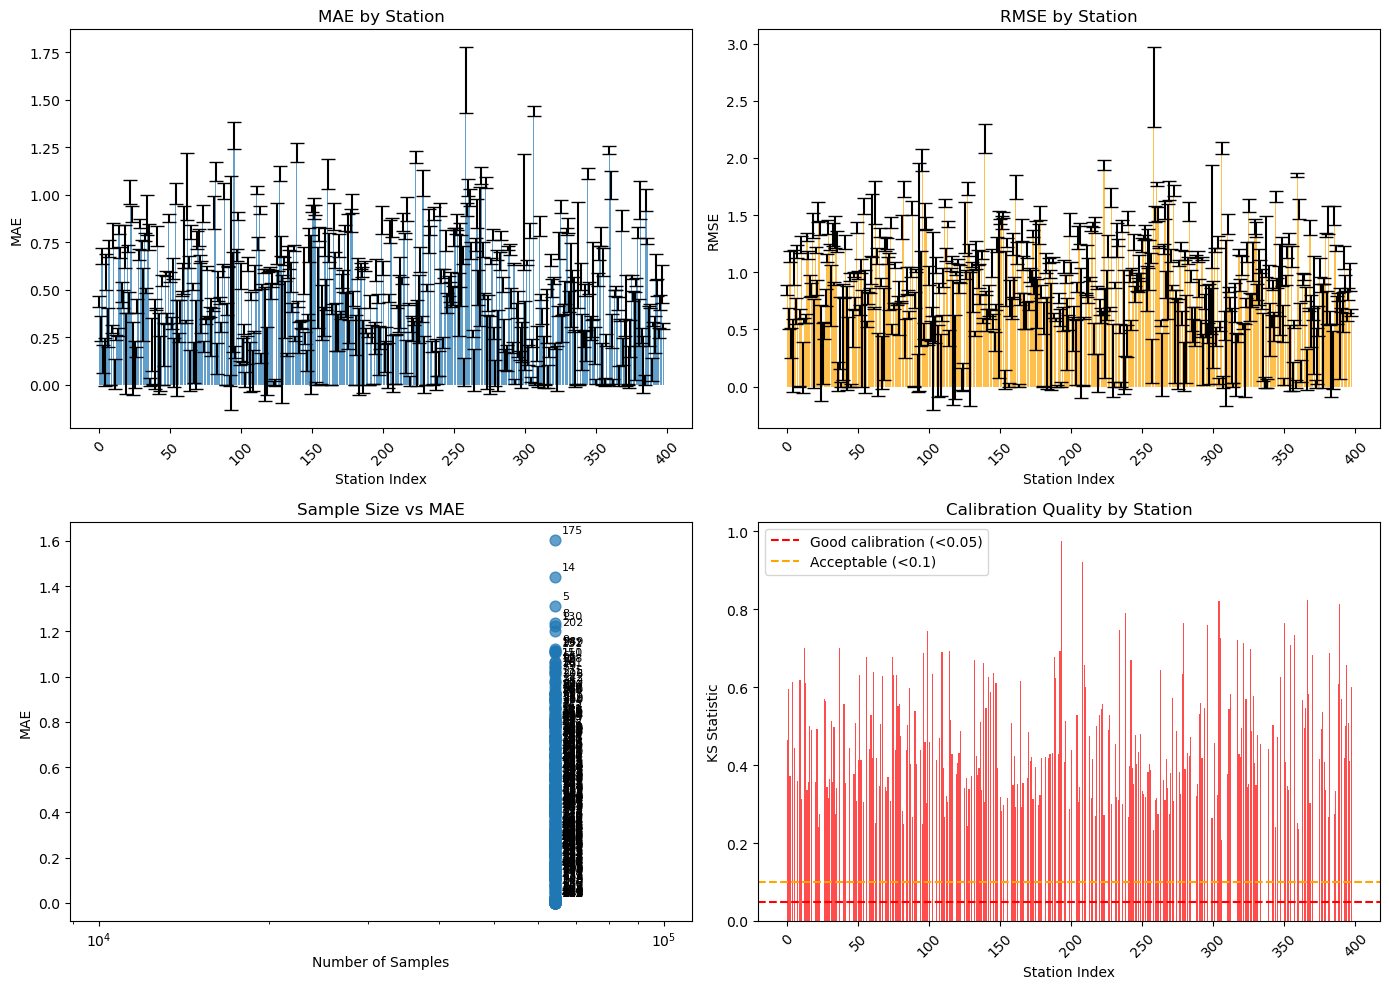

In [36]:
# Visualization of per-station results
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

if len(successful_stations) > 0:
    # Plot 1: MAE by station
    station_ids = results_df['station_id'].values
    maes = results_df['mae_mean'].values
    mae_stds = results_df['mae_std'].values
    
    axes[0,0].bar(range(len(station_ids)), maes, yerr=mae_stds, alpha=0.7, capsize=5)
    axes[0,0].set_xlabel('Station Index')
    axes[0,0].set_ylabel('MAE')
    axes[0,0].set_title('MAE by Station')
    axes[0,0].tick_params(axis='x', rotation=45)
    
    # Plot 2: RMSE by station
    rmses = results_df['rmse_mean'].values
    rmse_stds = results_df['rmse_std'].values
    
    axes[0,1].bar(range(len(station_ids)), rmses, yerr=rmse_stds, alpha=0.7, color='orange', capsize=5)
    axes[0,1].set_xlabel('Station Index')
    axes[0,1].set_ylabel('RMSE')
    axes[0,1].set_title('RMSE by Station')
    axes[0,1].tick_params(axis='x', rotation=45)
    
    # Plot 3: Sample size vs MAE
    sample_sizes = results_df['n_samples'].values
    axes[1,0].scatter(sample_sizes, maes, alpha=0.7, s=60)
    axes[1,0].set_xlabel('Number of Samples')
    axes[1,0].set_ylabel('MAE')
    axes[1,0].set_title('Sample Size vs MAE')
    axes[1,0].set_xscale('log')
    
    # Add station ID labels to points
    for i, station_id in enumerate(station_ids):
        axes[1,0].annotate(f'{station_id}', (sample_sizes[i], maes[i]), 
                          xytext=(5, 5), textcoords='offset points', fontsize=8)
    
    # Plot 4: Calibration quality
    ks_stats = results_df['pit_ks_mean'].values
    colors = ['green' if ks < 0.05 else 'orange' if ks < 0.1 else 'red' for ks in ks_stats]
    
    axes[1,1].bar(range(len(station_ids)), ks_stats, alpha=0.7, color=colors)
    axes[1,1].axhline(y=0.05, color='red', linestyle='--', label='Good calibration (<0.05)')
    axes[1,1].axhline(y=0.1, color='orange', linestyle='--', label='Acceptable (<0.1)')
    axes[1,1].set_xlabel('Station Index')
    axes[1,1].set_ylabel('KS Statistic')
    axes[1,1].set_title('Calibration Quality by Station')
    axes[1,1].legend()
    axes[1,1].tick_params(axis='x', rotation=45)

else:
    for ax in axes.flat:
        ax.text(0.5, 0.5, 'No successful stations', ha='center', va='center', transform=ax.transAxes)
        ax.set_title('No Data Available')

plt.tight_layout()
plt.show()


In [20]:
# Compare with global baseline (if available)
print("=== COMPARISON WITH GLOBAL BASELINE ===")

if len(successful_stations) > 0:
    # Calculate weighted average (by sample size)
    total_samples = results_df['n_samples'].sum()
    weighted_mae = (results_df['mae_mean'] * results_df['n_samples']).sum() / total_samples
    weighted_rmse = (results_df['rmse_mean'] * results_df['n_samples']).sum() / total_samples
    
    print(f"Per-Station Baseline (Weighted by Sample Size):")
    print(f"  Weighted MAE: {weighted_mae:.3f}")
    print(f"  Weighted RMSE: {weighted_rmse:.3f}")
    
    # Simple average
    print(f"\nPer-Station Baseline (Simple Average):")
    print(f"  Average MAE: {results_df['mae_mean'].mean():.3f}")
    print(f"  Average RMSE: {results_df['rmse_mean'].mean():.3f}")
    
    # From original baseline (approximate values based on global baseline)
    print(f"\nGlobal Baseline (Reference from original baseline.ipynb):")
    print(f"  Global MAE: ~0.434")
    print(f"  Global RMSE: ~0.994")
    
    # Performance improvement analysis
    improvement_mae = (0.434 - weighted_mae) / 0.434 * 100
    improvement_rmse = (0.994 - weighted_rmse) / 0.994 * 100
    
    print(f"\nPer-Station vs Global Improvement:")
    print(f"  MAE improvement: {improvement_mae:+.1f}%")
    print(f"  RMSE improvement: {improvement_rmse:+.1f}%")
    
    if improvement_mae > 0:
        print("  ✅ Per-station approach shows MAE improvement!")
    else:
        print("  ⚠️ Per-station approach shows MAE degradation")
        
    if improvement_rmse > 0:
        print("  ✅ Per-station approach shows RMSE improvement!")
    else:
        print("  ⚠️ Per-station approach shows RMSE degradation")

else:
    print("No successful stations to compare")


=== COMPARISON WITH GLOBAL BASELINE ===
Per-Station Baseline (Weighted by Sample Size):
  Weighted MAE: 0.460
  Weighted RMSE: 3.368

Per-Station Baseline (Simple Average):
  Average MAE: 0.460
  Average RMSE: 3.368

Global Baseline (Reference from original baseline.ipynb):
  Global MAE: ~0.434
  Global RMSE: ~0.994

Per-Station vs Global Improvement:
  MAE improvement: -6.0%
  RMSE improvement: -238.9%
  ⚠️ Per-station approach shows MAE degradation
  ⚠️ Per-station approach shows RMSE degradation
